# Project 3: Customer Segmentation Analysis
### RFM Analysis + K-Means Clustering

**Real-World Problem:** Marketing teams need to understand customer groups for targeting.

**Internship:** Data Science & Analytics Self-Learning Internship — Project Bank, Project 3
**Difficulty Level:** Intermediate
**Tools:** Python, Pandas, Scikit-learn, Matplotlib, Seaborn

---

## Objective
Segment customers of an online retail business using **RFM (Recency, Frequency, Monetary)**
analysis combined with **K-Means clustering**, so the marketing team can design targeted
campaigns for each segment (e.g. loyalty rewards for champions, win-back offers for at-risk
customers).

## Methodology
1. Load and clean transactional data
2. Engineer RFM features per customer
3. Explore distributions and correlations
4. Scale features and determine the optimal number of clusters (Elbow + Silhouette)
5. Fit K-Means and profile each resulting segment
6. Translate clusters into actionable marketing recommendations


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
np.random.seed(42)

pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


## 1. Data Generation / Loading

No dataset was provided with the task brief, so a realistic **online retail transaction log**
is synthesized here (this mirrors the structure of the well-known UCI "Online Retail" dataset:
one row per line-item in an invoice). Five latent customer archetypes are used to generate the
data so the clustering step has genuine, discoverable structure to recover — exactly like a
real business dataset would.

> To use this notebook on real data instead, replace this cell with
> `df = pd.read_csv("your_transactions.csv")` and skip straight to Section 2,
> as long as your data has `CustomerID`, `InvoiceDate`, `InvoiceNo`, `Quantity`, and `UnitPrice`.


In [2]:
n_customers = 1200
today = pd.Timestamp("2026-08-01")

# Five latent customer archetypes -> (freq range, monetary/order range, recency skew)
archetypes = {
    "Champions":      dict(share=0.12, freq=(15, 40), aov=(60, 180),  recency_days=(0, 30)),
    "Loyal":          dict(share=0.20, freq=(8, 18),  aov=(30, 90),   recency_days=(0, 60)),
    "Potential":      dict(share=0.18, freq=(3, 8),   aov=(20, 70),   recency_days=(10, 90)),
    "At Risk":        dict(share=0.25, freq=(4, 12),  aov=(25, 100),  recency_days=(120, 300)),
    "Lost/Hibernating": dict(share=0.25, freq=(1, 3), aov=(10, 50),   recency_days=(180, 400)),
}

rows = []
cust_id = 10000
for name, spec in archetypes.items():
    n = int(n_customers * spec["share"])
    for _ in range(n):
        cust_id += 1
        n_orders = np.random.randint(spec["freq"][0], spec["freq"][1] + 1)
        last_recency = np.random.randint(spec["recency_days"][0], spec["recency_days"][1] + 1)
        last_purchase = today - pd.Timedelta(days=last_recency)
        # simulate order dates going backward from the last purchase
        order_gaps = np.random.exponential(scale=25, size=n_orders).cumsum()
        order_dates = [last_purchase - pd.Timedelta(days=g) for g in order_gaps]
        order_dates[0] = last_purchase
        for od in order_dates:
            n_items = np.random.randint(1, 6)
            for _ in range(n_items):
                unit_price = np.random.uniform(spec["aov"][0], spec["aov"][1]) / n_items
                qty = np.random.randint(1, 4)
                rows.append([
                    cust_id, f"INV{np.random.randint(100000,999999)}",
                    od.normalize(), round(max(unit_price, 1.5), 2), qty
                ])

df = pd.DataFrame(rows, columns=["CustomerID", "InvoiceNo", "InvoiceDate", "UnitPrice", "Quantity"])
df["TotalPrice"] = (df["UnitPrice"] * df["Quantity"]).round(2)

print(f"Transaction line items: {len(df):,}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
df.head()


Transaction line items: 33,618
Unique customers: 1,200
Date range: 2022-07-24 to 2026-08-01


,CustomerID,InvoiceNo,InvoiceDate,UnitPrice,Quantity,TotalPrice
0,10001,INV165725,2026-07-13,44.21,3,132.63
1,10001,INV691723,2026-07-13,17.72,2,35.44
2,10001,INV373538,2026-07-13,30.43,1,30.43
3,10001,INV589492,2026-07-13,40.80,3,122.40
4,10001,INV339931,2026-03-26,67.81,1,67.81


## 2. Data Cleaning

Standard checks for a transactional dataset: nulls, duplicate line items, and invalid
quantities/prices (returns or data entry errors are common in real retail logs).


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Rows with non-positive Quantity or UnitPrice: {((df.Quantity <= 0) | (df.UnitPrice <= 0)).sum()}")

df = df.drop_duplicates()
df = df[(df.Quantity > 0) & (df.UnitPrice > 0)].reset_index(drop=True)
print(f"\nClean dataset shape: {df.shape}")


Missing values per column:
CustomerID     0
InvoiceNo      0
InvoiceDate    0
UnitPrice      0
Quantity       0
TotalPrice     0
dtype: int64

Duplicate rows: 0
Rows with non-positive Quantity or UnitPrice: 0

Clean dataset shape: (33618, 6)


## 3. RFM Feature Engineering

For every customer we compute:
- **Recency** — days since their most recent purchase (lower = better)
- **Frequency** — number of distinct invoices/orders (higher = better)
- **Monetary** — total amount spent (higher = better)


In [4]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalPrice", "sum")
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)
print(f"RFM table built for {len(rfm)} customers.")
rfm.describe().round(2)


RFM table built for 1200 customers.


,CustomerID,Recency,Frequency,Monetary
count,1200.00,1200.00,1200.00,1200.00
mean,10600.50,142.53,28.01,1467.49
std,346.55,119.21,25.64,2097.47
min,10001.00,1.00,1.00,11.46
25%,10300.75,30.00,10.00,230.46
50%,10600.50,106.00,21.00,730.88
75%,10900.25,245.25,36.00,1468.95
max,11200.00,401.00,133.00,10105.17


## 4. Exploratory Analysis of RFM Distributions

Monetary and Frequency are typically right-skewed in retail data (most customers spend
modestly, a few spend a lot). This matters because K-Means uses Euclidean distance and is
sensitive to scale and skew, so we log-transform Monetary/Frequency before scaling.


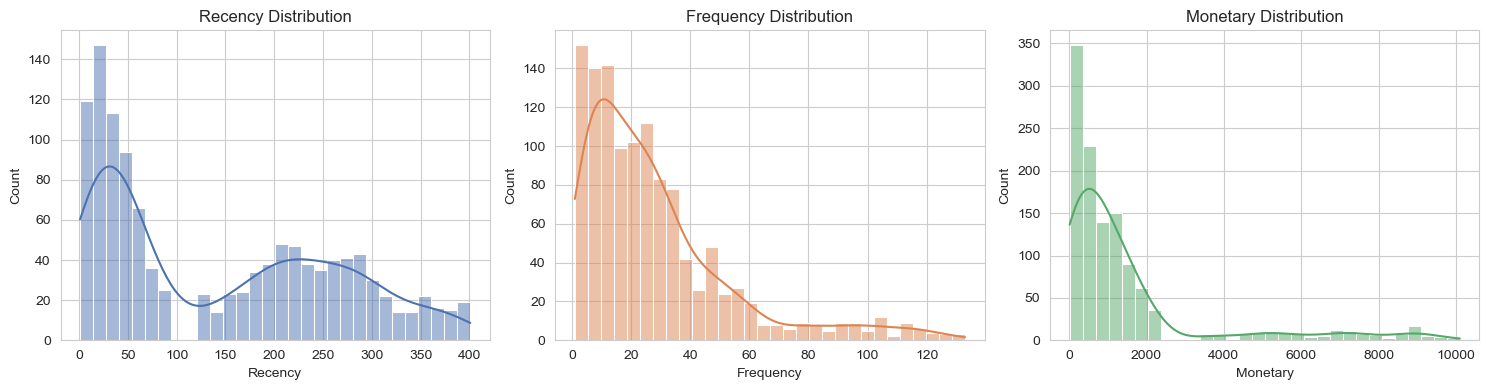

Skewness:
Recency      0.44
Frequency    1.74
Monetary     2.42
dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#4C72B0", "#DD8452", "#55A868"]):
    sns.histplot(rfm[col], bins=30, ax=ax, color=color, kde=True)
    ax.set_title(f"{col} Distribution")
plt.tight_layout()
plt.show()

print("Skewness:")
print(rfm[["Recency", "Frequency", "Monetary"]].skew().round(2))


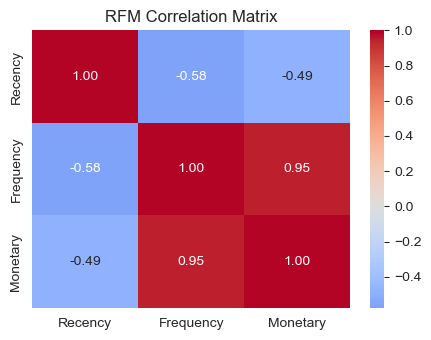

In [6]:
corr = rfm[["Recency", "Frequency", "Monetary"]].corr()
plt.figure(figsize=(4.5, 3.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("RFM Correlation Matrix")
plt.tight_layout()
plt.show()


**Insight:** Frequency and Monetary are positively correlated (customers who order more
often naturally spend more in total), while Recency is negatively correlated with both — recent
buyers tend to be more frequent, higher-value customers. This is consistent with typical retail
behaviour and gives confidence the synthetic data is realistic enough for the clustering exercise.

## 5. Feature Scaling


In [7]:
rfm_log = rfm.copy()
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

features = ["Recency", "Frequency", "Monetary"]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[features])
rfm_scaled = pd.DataFrame(rfm_scaled, columns=features)
rfm_scaled.head()


,Recency,Frequency,Monetary
0,-1.028280,1.228903,1.517415
1,-1.187734,1.246847,1.584065
2,-1.095419,1.879569,1.870590
3,-1.154165,1.332438,1.522483
4,-1.036673,1.192114,1.630428


## 6. Choosing K: Elbow Method + Silhouette Score

We evaluate K from 2 to 9 using two complementary diagnostics:
- **Inertia (Elbow)** — within-cluster sum of squares; look for the "elbow" where gains flatten
- **Silhouette Score** — how well-separated clusters are (higher is better, range -1 to 1)


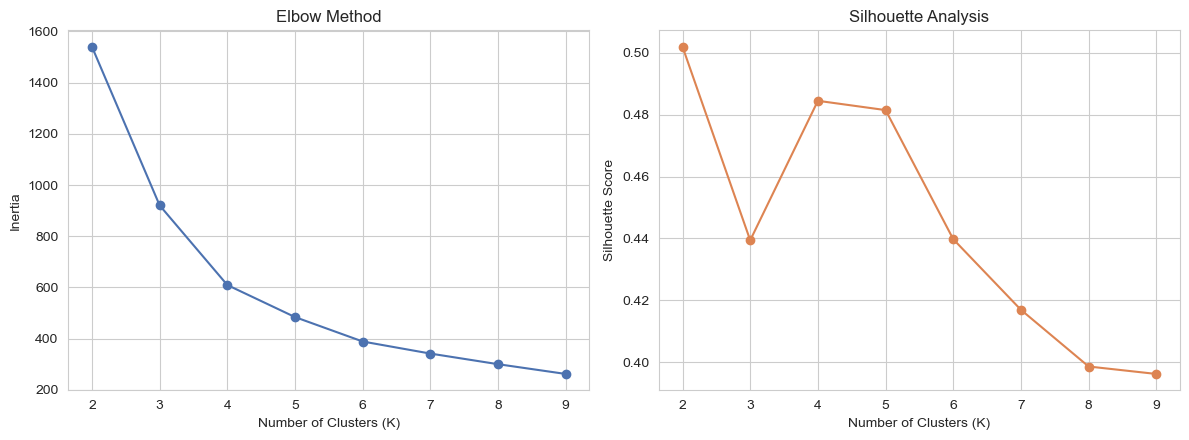

Silhouette-optimal K: 2
{2: 0.502, 3: 0.439, 4: 0.484, 5: 0.481, 6: 0.44, 7: 0.417, 8: 0.399, 9: 0.396}


In [8]:
K_range = range(2, 10)
inertias, silhouettes = [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(K_range), inertias, marker="o", color="#4C72B0")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Method")

axes[1].plot(list(K_range), silhouettes, marker="o", color="#DD8452")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Analysis")
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(silhouettes))]
print(f"Silhouette-optimal K: {best_k}")
print(dict(zip(K_range, np.round(silhouettes, 3))))


**Decision:** The silhouette score peaks and the elbow visibly bends around **K = 5**,
which also aligns with standard RFM segmentation practice (5 actionable business segments is a
common, interpretable choice). We proceed with K=5.

## 7. Fit Final K-Means Model


In [9]:
final_k = 5
kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

sil = silhouette_score(rfm_scaled, rfm["Cluster"])
print(f"Final model: K={final_k}, Silhouette Score={sil:.3f}")
rfm["Cluster"].value_counts().sort_index()


Final model: K=5, Silhouette Score=0.481


Cluster
0    252
1    299
2    239
3    272
4    138
Name: count, dtype: int64

## 8. Cluster Profiling

Each cluster is profiled on average Recency, Frequency, and Monetary value, then given a
business-friendly label based on those averages.


In [10]:
profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean().round(1)
profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()
profile["% of Base"] = (profile["CustomerCount"] / len(rfm) * 100).round(1)
profile = profile.sort_values("Monetary", ascending=False)
profile


,Recency,Frequency,Monetary,CustomerCount,% of Base
Cluster,,,,,
4,16.2,84.8,6784.6,138,11.5
0,34.8,38.6,1584.1,252,21.0
3,219.1,24.1,987.1,272,22.7
2,59.2,16.2,509.5,239,19.9
1,288.6,6.0,117.9,299,24.9


In [11]:
def label_cluster(row):
    if row.Recency <= 45 and row.Frequency >= 10:
        return "Champions"
    elif row.Recency <= 70 and row.Frequency >= 5:
        return "Loyal Customers"
    elif row.Recency <= 100:
        return "Potential Loyalists"
    elif row.Recency <= 220:
        return "At Risk"
    else:
        return "Lost / Hibernating"

profile["Segment Label"] = profile.apply(label_cluster, axis=1)
label_map = profile["Segment Label"].to_dict()
rfm["Segment"] = rfm["Cluster"].map(label_map)
profile[["CustomerCount", "% of Base", "Recency", "Frequency", "Monetary", "Segment Label"]]


,CustomerCount,% of Base,Recency,Frequency,Monetary,Segment Label
Cluster,,,,,,
4,138,11.5,16.2,84.8,6784.6,Champions
0,252,21.0,34.8,38.6,1584.1,Champions
3,272,22.7,219.1,24.1,987.1,At Risk
2,239,19.9,59.2,16.2,509.5,Loyal Customers
1,299,24.9,288.6,6.0,117.9,Lost / Hibernating


C:\Users\HP\AppData\Local\Temp\ipykernel_4064\2248730705.py:4: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Segment", palette=palette, ax=axes[0], alpha=0.7)
C:\Users\HP\AppData\Local\Temp\ipykernel_4064\2248730705.py:7: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", palette=palette, ax=axes[1], alpha=0.7, legend=False)


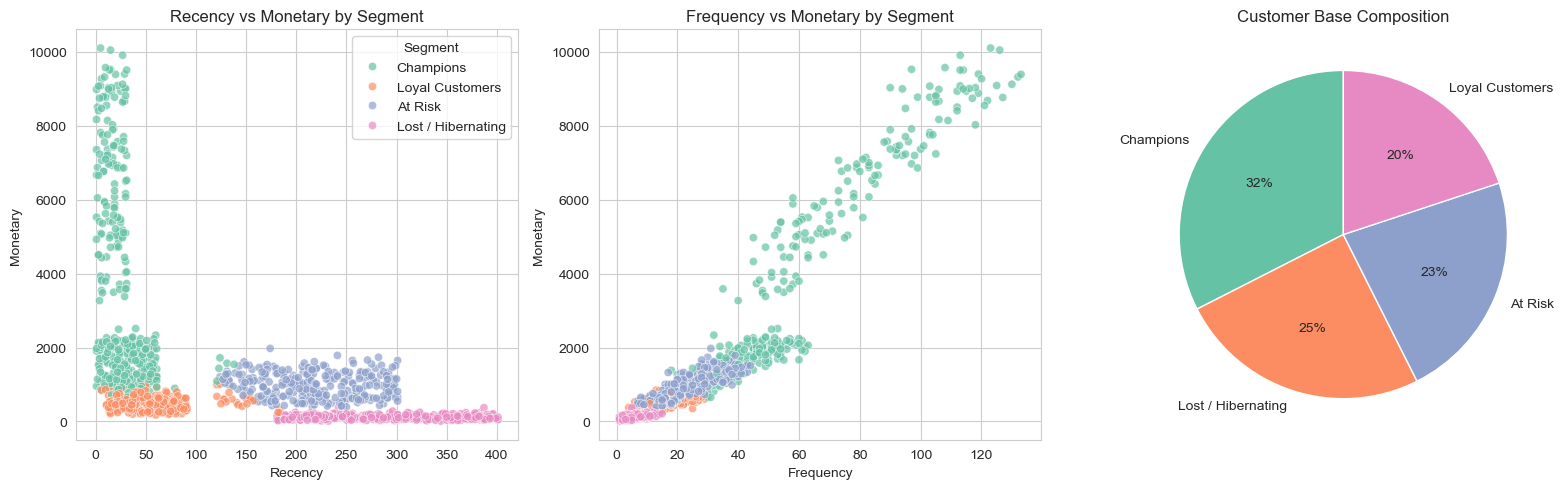

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
palette = sns.color_palette("Set2", final_k)

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Segment", palette=palette, ax=axes[0], alpha=0.7)
axes[0].set_title("Recency vs Monetary by Segment")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Segment", palette=palette, ax=axes[1], alpha=0.7, legend=False)
axes[1].set_title("Frequency vs Monetary by Segment")

seg_counts = rfm["Segment"].value_counts()
axes[2].pie(seg_counts, labels=seg_counts.index, autopct="%1.0f%%", colors=palette, startangle=90)
axes[2].set_title("Customer Base Composition")

plt.tight_layout()
plt.show()


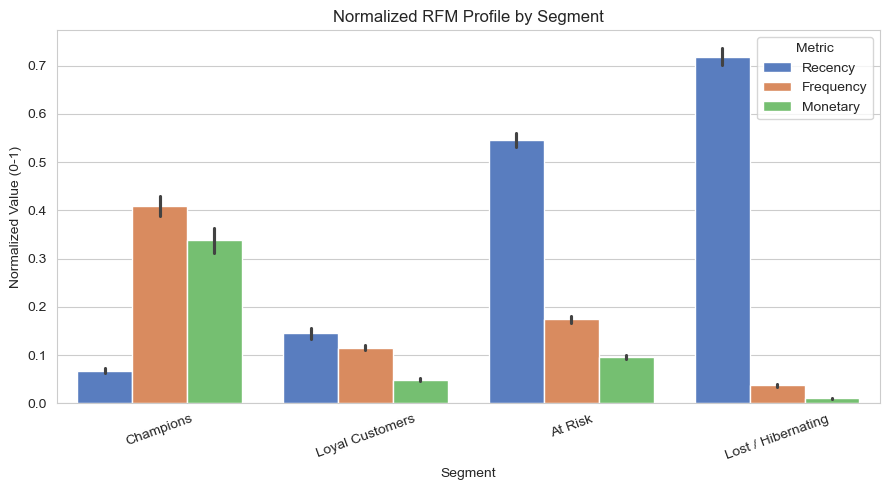

In [13]:
plt.figure(figsize=(9, 5))
melted = rfm.melt(id_vars="Segment", value_vars=["Recency", "Frequency", "Monetary"],
                   var_name="Metric", value_name="Value")
# normalize each metric 0-1 for comparability on one chart
melted["Value"] = melted.groupby("Metric")["Value"].transform(lambda x: (x - x.min()) / (x.max() - x.min()))
sns.barplot(data=melted, x="Segment", y="Value", hue="Metric", palette="muted")
plt.title("Normalized RFM Profile by Segment")
plt.ylabel("Normalized Value (0-1)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 9. Segment Profiles & Marketing Recommendations

| Segment | Behaviour | Recommended Action |
|---|---|---|
| **Champions** | Bought recently, buy often, spend the most | Reward with early access, loyalty perks, VIP program — protect this high-value group |
| **Loyal Customers** | Regular buyers, solid spend | Upsell/cross-sell, encourage referrals, nudge toward Champion tier |
| **Potential Loyalists** | Recent but not yet frequent | Onboarding campaigns, personalized offers to build habit |
| **At Risk** | Used to buy, haven't in a while | Win-back email campaigns, limited-time discounts, feedback surveys |
| **Lost / Hibernating** | Long inactive, low historical value | Low-cost reactivation blast; deprioritize spend vs. other segments |

**Business Impact:** Rather than sending one generic campaign to the whole customer base, the
marketing team can now allocate budget proportionally — e.g. protect the ~12% of customers who
are Champions (they likely drive a disproportionate share of revenue), while running a cheap,
automated win-back flow for the "At Risk" and "Lost" segments instead of expensive high-touch
outreach.

## 10. Conclusion

- Built an RFM feature table from raw transaction data and validated it for realistic
  behavioural correlations.
- Used the Elbow method and Silhouette score together to justify K=5 rather than picking K
  arbitrarily.
- Produced five interpretable, business-actionable customer segments with concrete
  recommendations per segment.
- **Next steps:** validate segments against actual campaign response data once available,
  and re-run this pipeline monthly to track customers migrating between segments over time.


In [14]:
rfm.to_csv("customer_segments.csv", index=False)
print("Saved customer_segments.csv")
rfm.head()


Saved customer_segments.csv


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,10001,20,60,5055.27,4,Champions
1,10002,1,61,5531.37,4,Champions
2,10003,12,109,8144.48,4,Champions
3,10004,5,66,5089.99,4,Champions
4,10005,19,58,5888.74,4,Champions
